# UV-Vis Analysis: Band Gap Determination

This notebook analyzes UV-Vis spectroscopy data to determine the optical band gap of thin film semiconductor materials. The analysis is divided into three main sections:

1. **Absorption Coefficient Calculation** - Converts reflectance and transmittance data to absorption coefficient
2. **Combined Tauc Plot Overview** - Generates comparison plots of all samples
3. **Individual Tauc Plots & Band Gap Extraction** - Calculates optical band gaps using the Tauc method

## Methodology: Absorption Coefficient Determination

To calculate the band gap of a thin film from UV-Vis transmittance data, the absorption coefficient is calculated using the following formula:

$$\alpha_{comp} = +\frac{1}{t} \cdot \ln \left( \frac{(1-R)^2}{T} + \sqrt{\frac{(1-R)^4}{4T^2} + R^2} \right) \quad \text{(1)}$$

Where:
- **α** is the absorption coefficient (cm⁻¹)
- **t** is the thickness of the film (cm)
- **T** is the transmittance
- **R** is the reflectance

### Photon Energy Calculation

The photon energy in eV is calculated from the wavelength using:

$$h\nu = \frac{hc}{\lambda} \cdot \frac{1}{e} \quad \text{(2)}$$

Where:
- **h** is Planck's constant (6.626 × 10⁻³⁴ J·s)
- **c** is the speed of light (3 × 10⁸ m/s)
- **λ** is the wavelength (nm)
- **e** is the elemental charge (1 eV conversion factor)

C:\Users\jp_ol\AppData\Local\Temp\ipykernel_12192\3314901449.py:61: RuntimeWarning: divide by zero encountered in divide
  rt = (1 - reflectance)**2/(transmittance) + np.sqrt( (1 - reflectance)**4/(4*transmittance**2) +  reflectance**2  )
C:\Users\jp_ol\AppData\Local\Temp\ipykernel_12192\3314901449.py:61: RuntimeWarning: divide by zero encountered in divide
  rt = (1 - reflectance)**2/(transmittance) + np.sqrt( (1 - reflectance)**4/(4*transmittance**2) +  reflectance**2  )
C:\Users\jp_ol\AppData\Local\Temp\ipykernel_12192\3314901449.py:61: RuntimeWarning: divide by zero encountered in divide
  rt = (1 - reflectance)**2/(transmittance) + np.sqrt( (1 - reflectance)**4/(4*transmittance**2) +  reflectance**2  )


C:\Users\jp_ol\AppData\Local\Temp\ipykernel_12192\3314901449.py:61: RuntimeWarning: divide by zero encountered in divide
  rt = (1 - reflectance)**2/(transmittance) + np.sqrt( (1 - reflectance)**4/(4*transmittance**2) +  reflectance**2  )
C:\Users\jp_ol\AppData\Local\Temp\ipykernel_12192\3314901449.py:61: RuntimeWarning: divide by zero encountered in divide
  rt = (1 - reflectance)**2/(transmittance) + np.sqrt( (1 - reflectance)**4/(4*transmittance**2) +  reflectance**2  )
C:\Users\jp_ol\AppData\Local\Temp\ipykernel_12192\3314901449.py:61: RuntimeWarning: divide by zero encountered in divide
  rt = (1 - reflectance)**2/(transmittance) + np.sqrt( (1 - reflectance)**4/(4*transmittance**2) +  reflectance**2  )


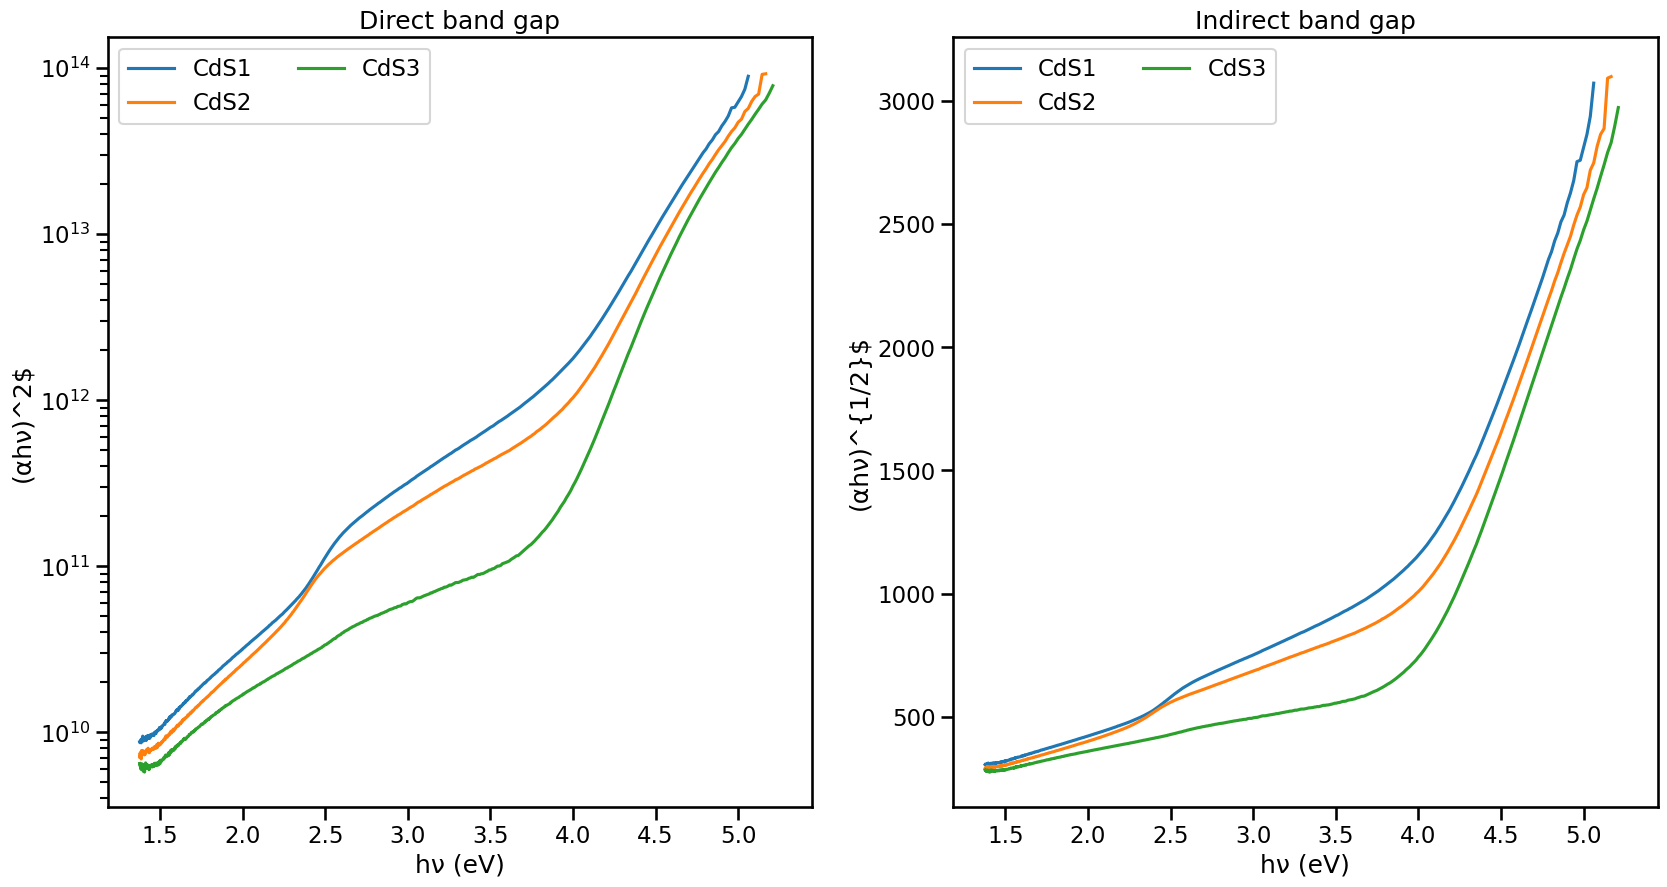

C:\Users\jp_ol\AppData\Local\Temp\ipykernel_12192\3314901449.py:61: RuntimeWarning: divide by zero encountered in divide
  rt = (1 - reflectance)**2/(transmittance) + np.sqrt( (1 - reflectance)**4/(4*transmittance**2) +  reflectance**2  )
C:\Users\jp_ol\AppData\Local\Temp\ipykernel_12192\3314901449.py:61: RuntimeWarning: divide by zero encountered in divide
  rt = (1 - reflectance)**2/(transmittance) + np.sqrt( (1 - reflectance)**4/(4*transmittance**2) +  reflectance**2  )
C:\Users\jp_ol\AppData\Local\Temp\ipykernel_12192\3314901449.py:61: RuntimeWarning: divide by zero encountered in divide
  rt = (1 - reflectance)**2/(transmittance) + np.sqrt( (1 - reflectance)**4/(4*transmittance**2) +  reflectance**2  )


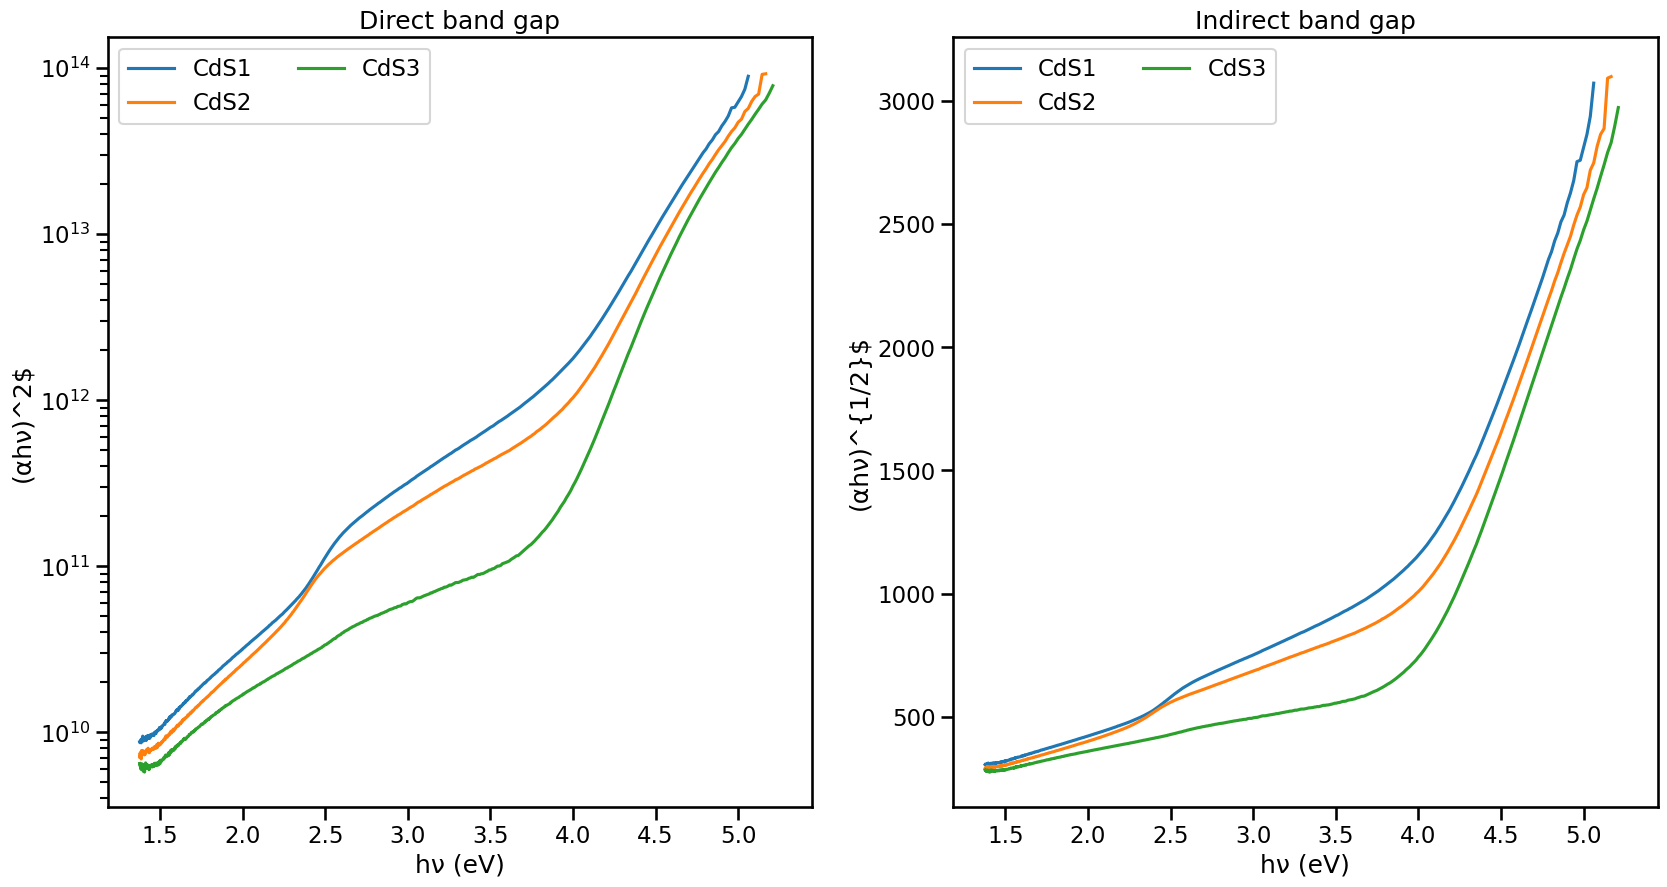

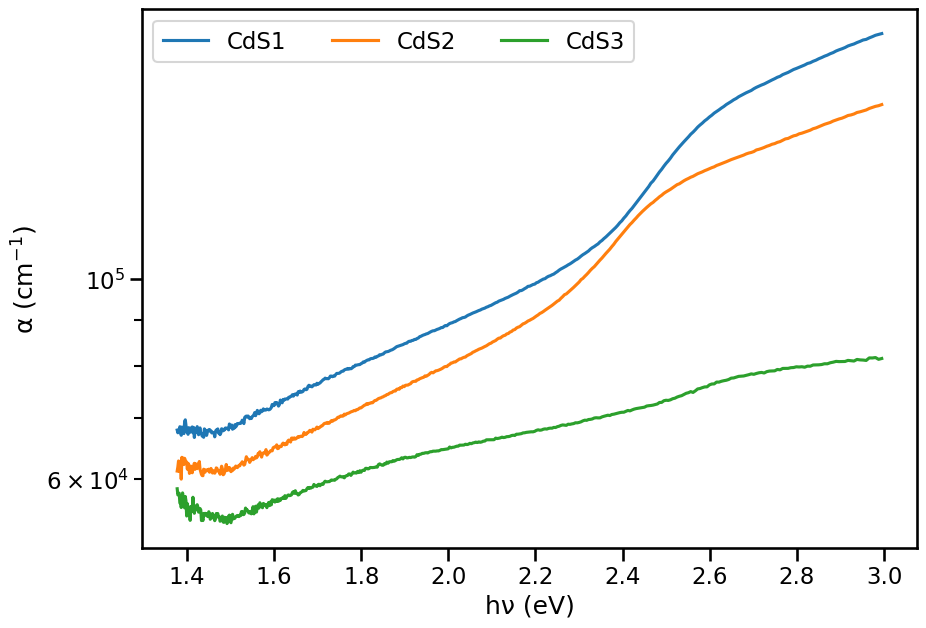

In [20]:
#Required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import glob as gl
import seaborn as sns
import os

# File path to the Excel file
FILE_PATH = "C:/Users/jp_ol/OneDrive/Ambiente de Trabalho/TESE/Data_Analysis/data/UV-Vis/CdS_JOliveira_7abr26.xlsx"

# Set output directory for plots
PLOTS_DIR = "Plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# Physical constants
h = 6.62607015e-34  # Planck's constant (J·s)
c = 299792458       # Speed of light (m/s)
e = 1.602176634e-19 # Elementary charge (C)

# Load all sheets from Excel
xls = pd.ExcelFile(FILE_PATH)
sheet_names = xls.sheet_names

# Dictionary to store processed data
res = {}

sns.set_context('talk')

#Create the Tauc plots for all the samples
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20,10))
fig1, ax3 = plt.subplots(1, 1, figsize=(10, 7))

for sheet_name in sheet_names:
        # Read the sheet
        df = pd.read_excel(FILE_PATH, sheet_name=sheet_name)
        
        # Get wavelength and optical properties
        wavelength = df['wavelength'].values
        
        # Determine which columns contain T and R
        if 'T' in df.columns:
            transmittance = df['T'].values /100  # Convert percentage to fraction
        else:
            transmittance = df.iloc[:, 1].values /100  # Assume second column is T and convert to fraction
            
        if 'R' in df.columns:
            reflectance = df['R'].values /100  # Convert percentage to fraction
        else:
            reflectance = df.iloc[:, 2].values /100  # Assume third column is R and convert to fraction
        
        # Get thickness (in nm, convert to cm)
        if 'thickness' in df.columns:
            thickness_nm = df['thickness'].dropna().iloc[0]
        
        # Calculate absorption coefficient using the formula:
        # α = (1/t) * ln((1-R)²/T + sqrt((1-R)⁴/(4T²) + R²))
        #                |---------------rt---------------|    

        rt = (1 - reflectance)**2/(transmittance) + np.sqrt( (1 - reflectance)**4/(4*transmittance**2) +  reflectance**2  )

        x = (h * c)/ (wavelength * 10**-9) / e
        data_y = np.where(rt <= 0, 1E-10, rt)

        y = np.log(data_y)/ (thickness_nm * 1e-7)  # Convert nm to cm
        y_DA = (y*x)**(2)
        y_IA = (y*x)**(1/2)

        # Store in dictionary
        res[sheet_name] = {
            'hv': x,
            'alpha': y, # Store the calculated alpha values
            'DA': np.nan_to_num(y_DA),
            'IA': np.nan_to_num(y_IA),
            'nm': wavelength,
            'R': reflectance,
            'T': transmittance
        }
        
        # Plot the data
        ax1.plot(x,y_DA, label=sheet_name)
        ax2.plot(x,y_IA, label=sheet_name)

        #absorbance plot
        small_range_y = y[x<3]
        small_range_x = x[x<3]
        ax3.plot(small_range_x, small_range_y, label=sheet_name)

# Fix the graph of direct band gap
ax1.legend(ncols=2)
ax1.set_ylabel(r'(αhν)²')
ax1.set_xlabel(r'hν (eV)')
ax1.set_title('Direct band gap')
ax1.set_yscale("log")

# Fix the graph of indirect band gap
ax2.legend(ncols=2)
ax2.set_ylabel(r'(αhν)½')
ax2.set_xlabel(r'hν (eV)')
ax2.set_title('Indirect band gap')

# Fix the graph of indirect band gap
ax3.legend(ncols=3)
ax3.set_ylabel(r'α (cm$^{-1}$)')
ax3.set_xlabel(r'hν (eV)')
ax3.set_yscale("log")
#ax3.set_xlim([0,3])

# Save the values of the tauc plot in excel files
with pd.ExcelWriter(os.path.join(PLOTS_DIR, "results_tauc_plot.xlsx")) as writer:
  for label_plot, data in res.items():
      df_export = pd.DataFrame(data)
      df_export.to_excel(writer, index=False, sheet_name=label_plot )

# Save the combined plots
fig.savefig(os.path.join(PLOTS_DIR, 'Combined_Direct_Indirect_BandGap.png'), dpi=300, bbox_inches='tight')
fig1.savefig(os.path.join(PLOTS_DIR, 'Absorption_Coefficient.png'), dpi=300, bbox_inches='tight')

plt.show()

## Methodology: Tauc Plot and Band Gap Extraction

Following the Tauc method, the following mathematical relation is used to determine the optical band gap:

$$(h\nu \cdot \alpha)^{1/\gamma} = B(h\nu - E_g) \quad \text{(3)}$$

Where:
- **γ** denotes the nature of the transitions:
  - **γ = 2** for indirect allowed transitions
  - **γ = 1/2** for direct allowed transitions
- **B** is a constant
- **$E_g$** is the band gap energy (eV) - found by extrapolating the linear region to the x-axis

### Procedure

1. **Data Smoothing**: Apply Savitzky-Golay filter to reduce noise
2. **Linear Region Identification**: Find the region with maximum slope (derivative) in the Tauc plot
3. **Extrapolation**: Fit a line through the linear region
4. **Band Gap Extraction**: The x-intercept (where y=0) gives the optical band gap $E_g$

The direct band gap is obtained from $(\alpha h\nu)^2$ vs $h\nu$, while the indirect band gap is from $(\alpha h\nu)^{1/2}$ vs $h\nu$.


Processing sample: CdS1



Processing sample: CdS1


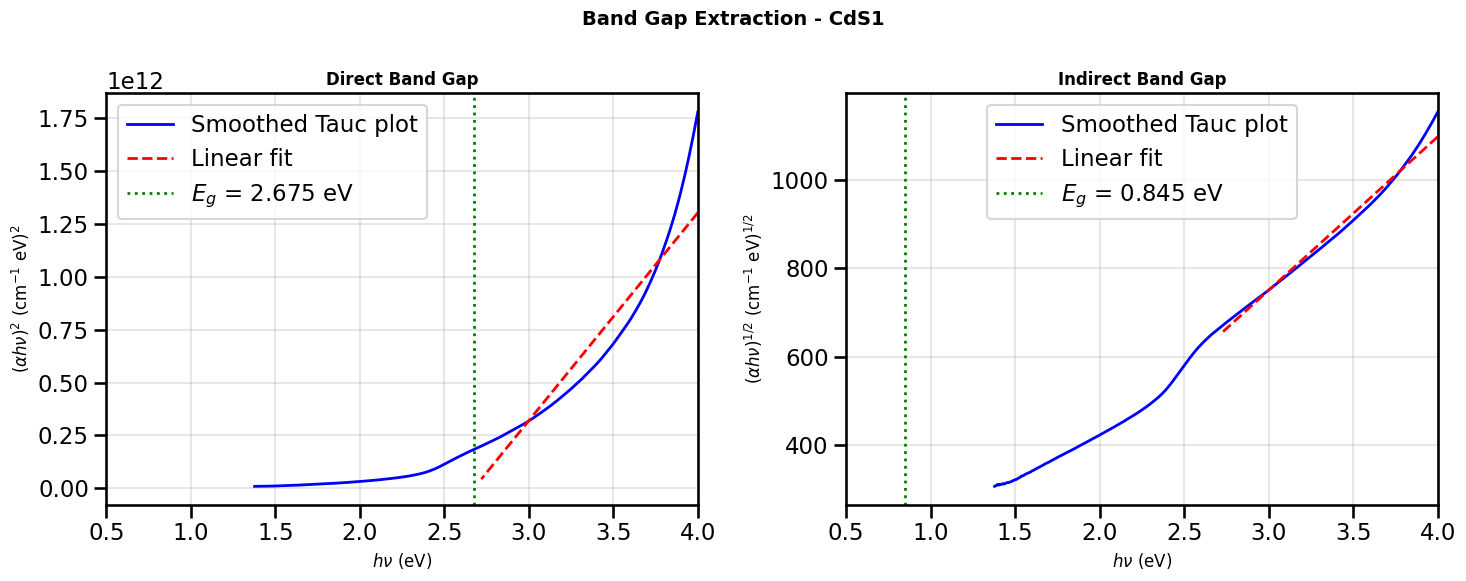


Processing sample: CdS1


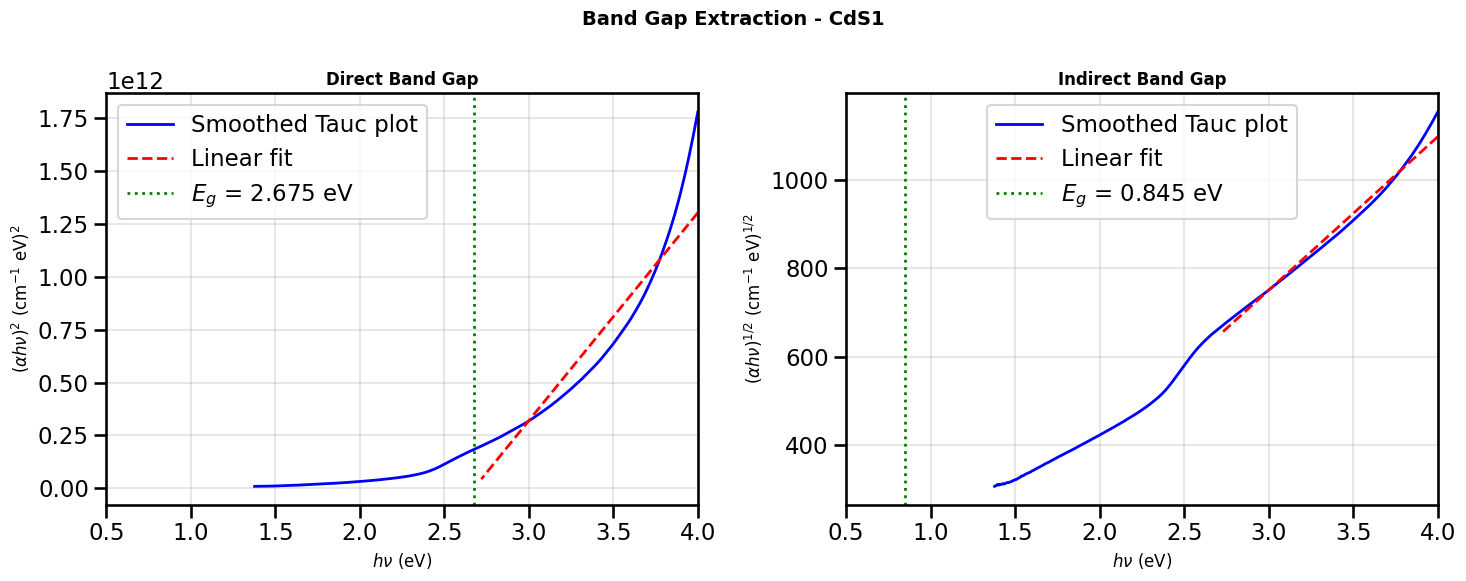

  Direct band gap: 2.675 eV
  Indirect band gap: 0.845 eV

Processing sample: CdS2



Processing sample: CdS1


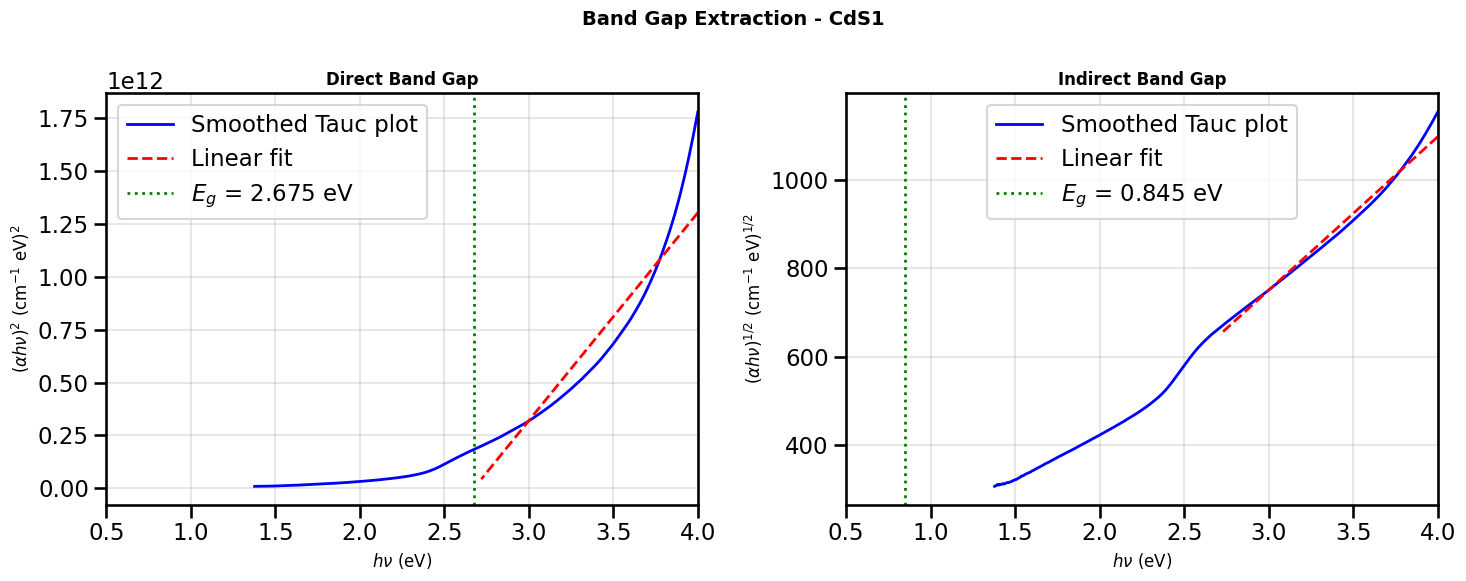

  Direct band gap: 2.675 eV
  Indirect band gap: 0.845 eV

Processing sample: CdS2


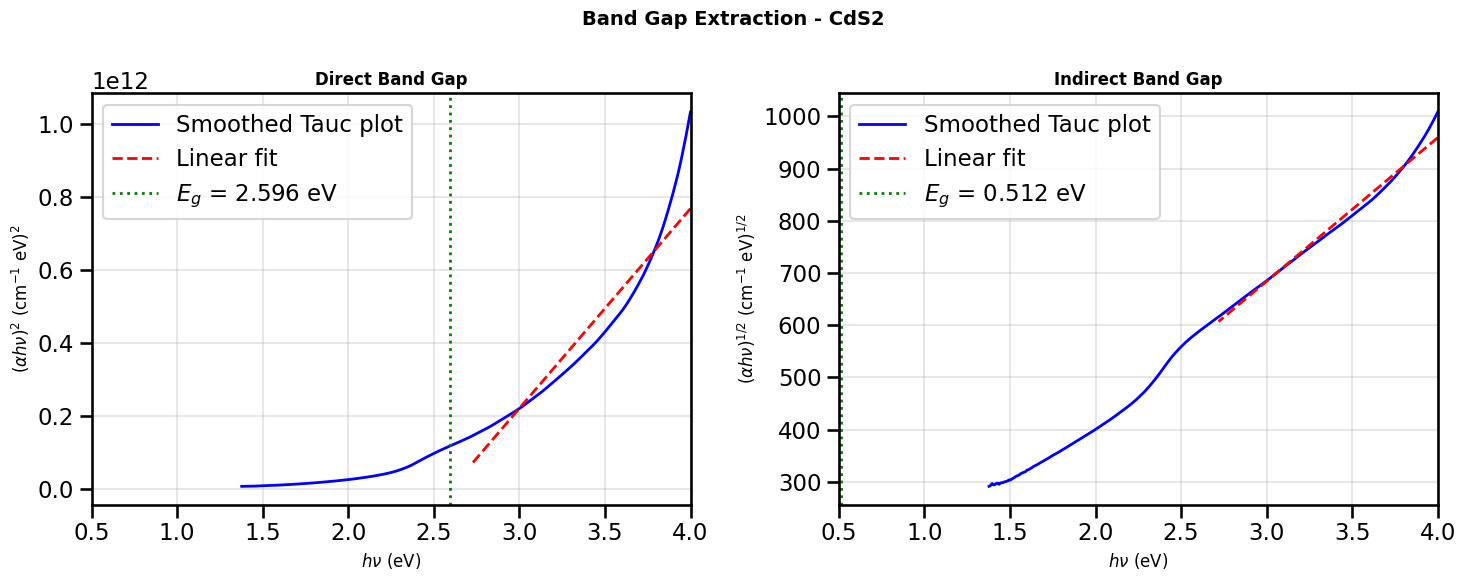


Processing sample: CdS1


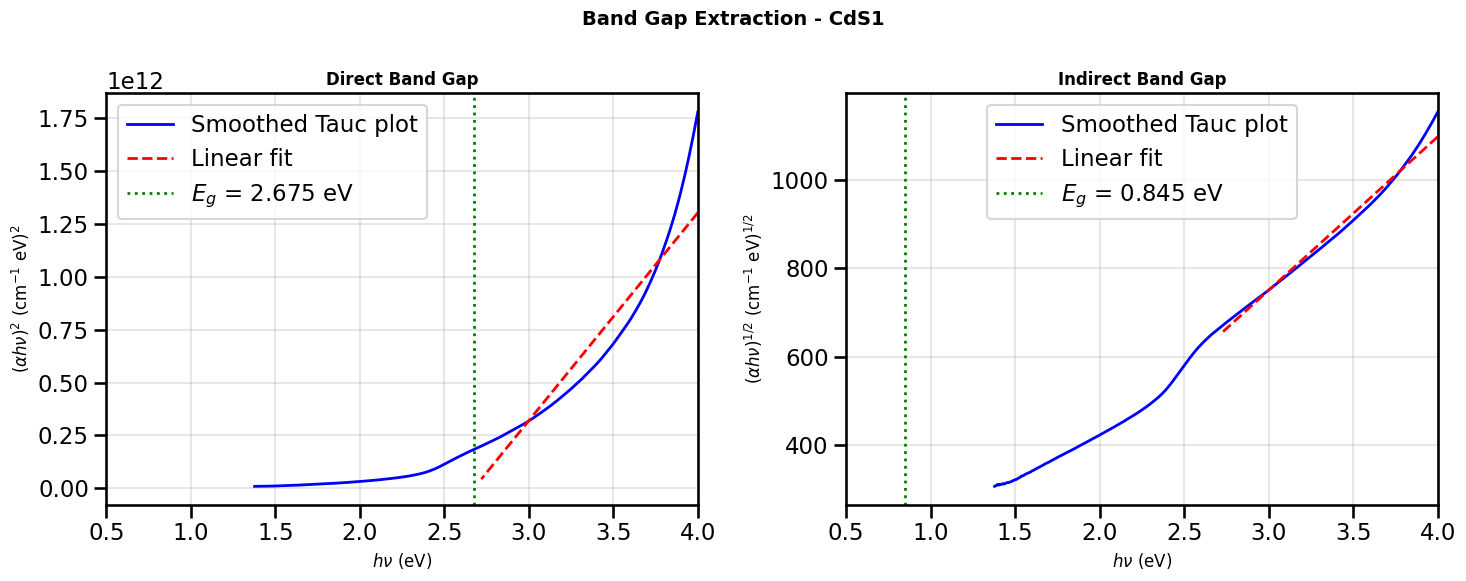

  Direct band gap: 2.675 eV
  Indirect band gap: 0.845 eV

Processing sample: CdS2


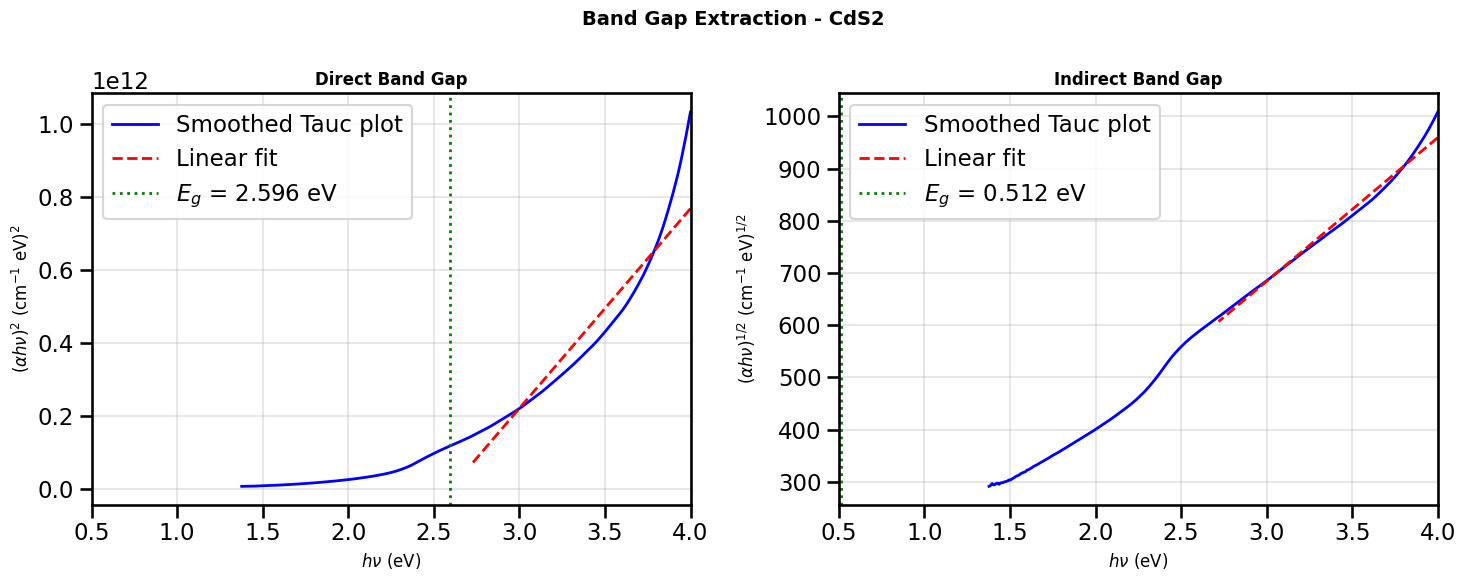

  Direct band gap: 2.596 eV
  Indirect band gap: 0.512 eV

Processing sample: CdS3



Processing sample: CdS1


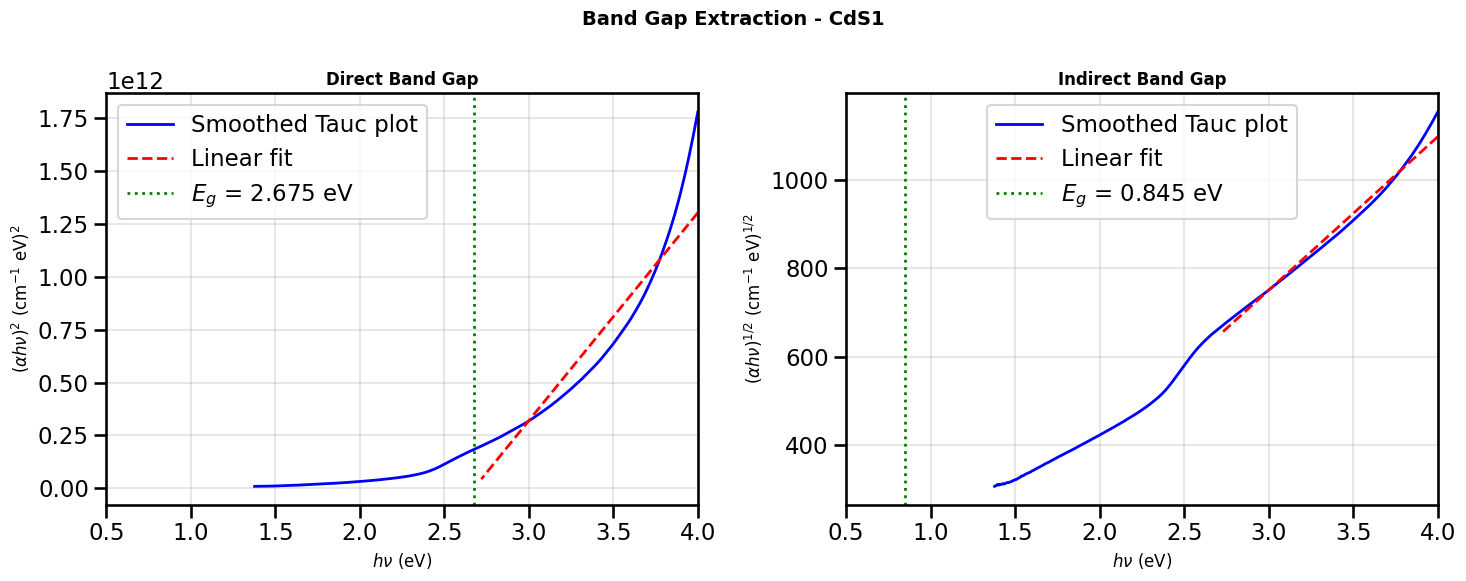

  Direct band gap: 2.675 eV
  Indirect band gap: 0.845 eV

Processing sample: CdS2


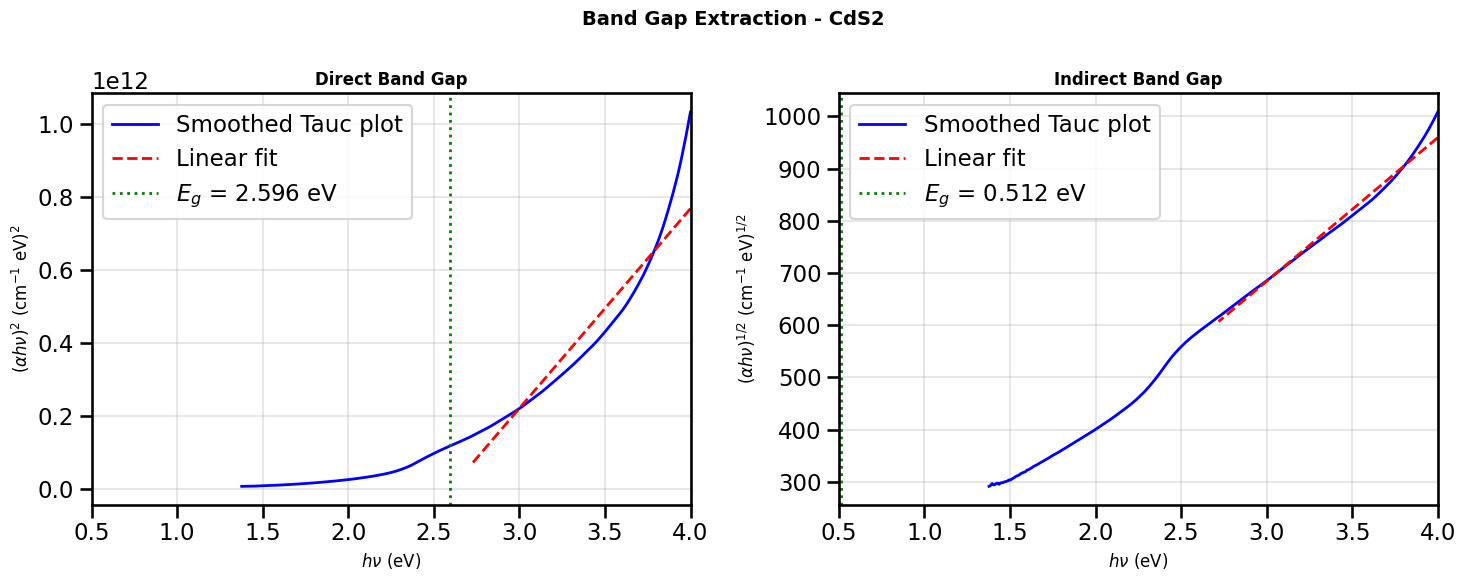

  Direct band gap: 2.596 eV
  Indirect band gap: 0.512 eV

Processing sample: CdS3


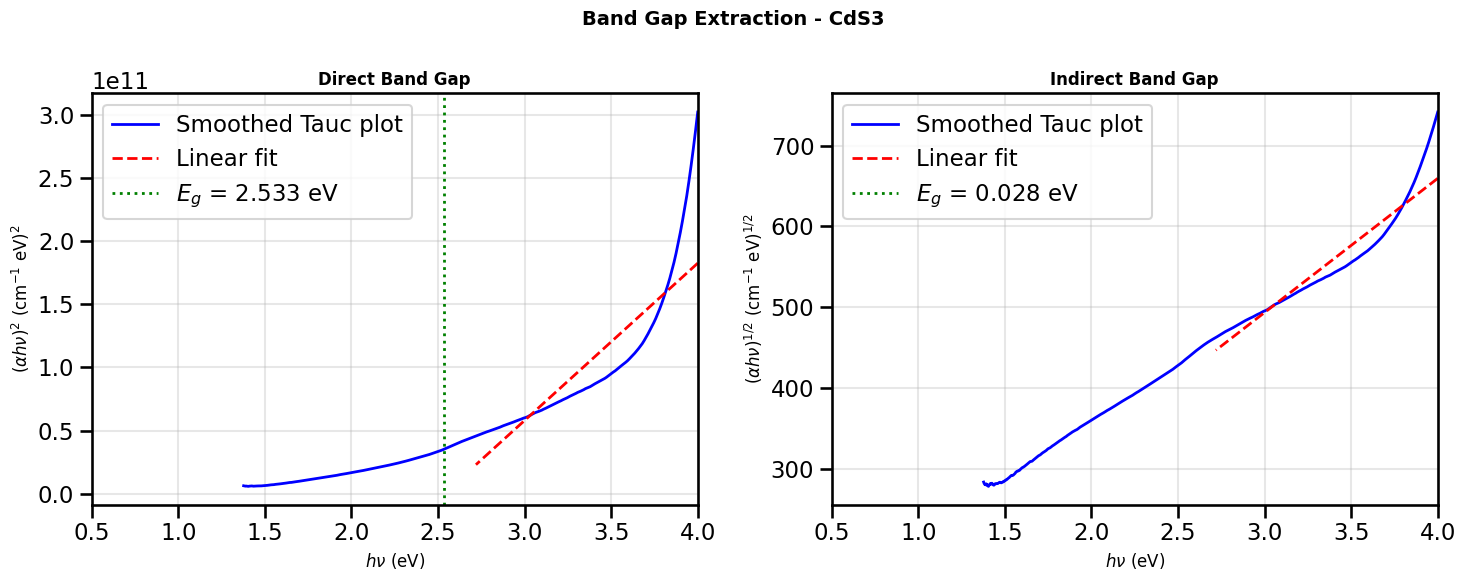


Processing sample: CdS1


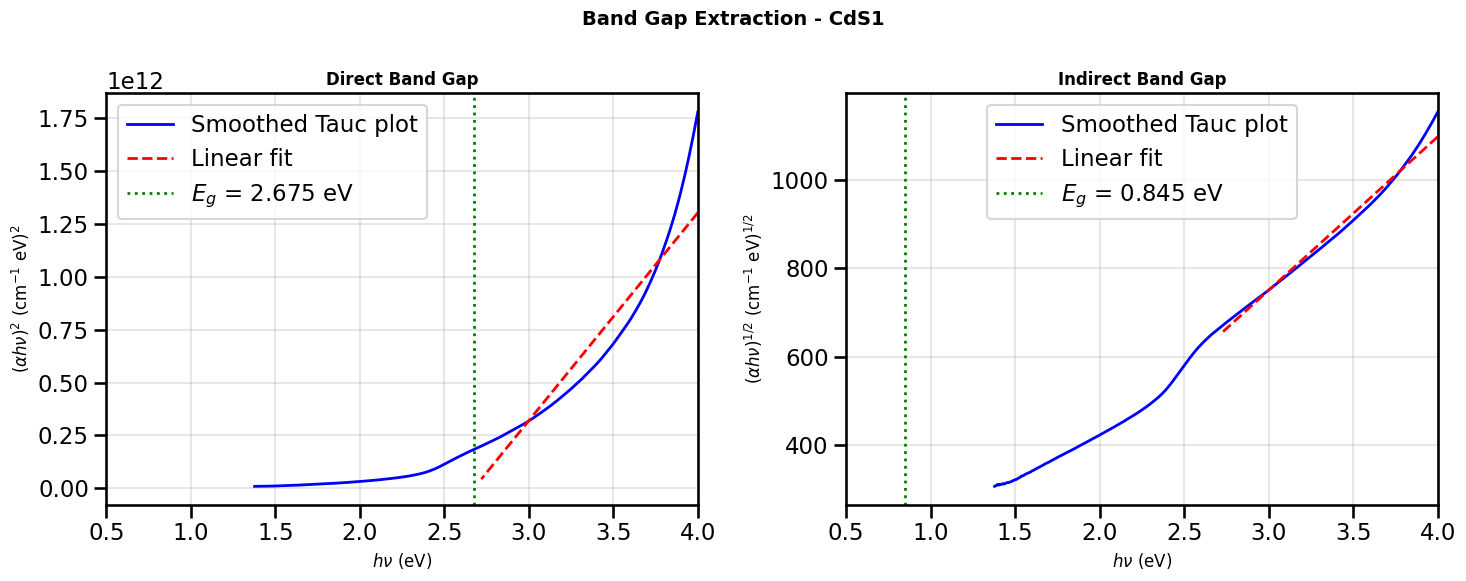

  Direct band gap: 2.675 eV
  Indirect band gap: 0.845 eV

Processing sample: CdS2


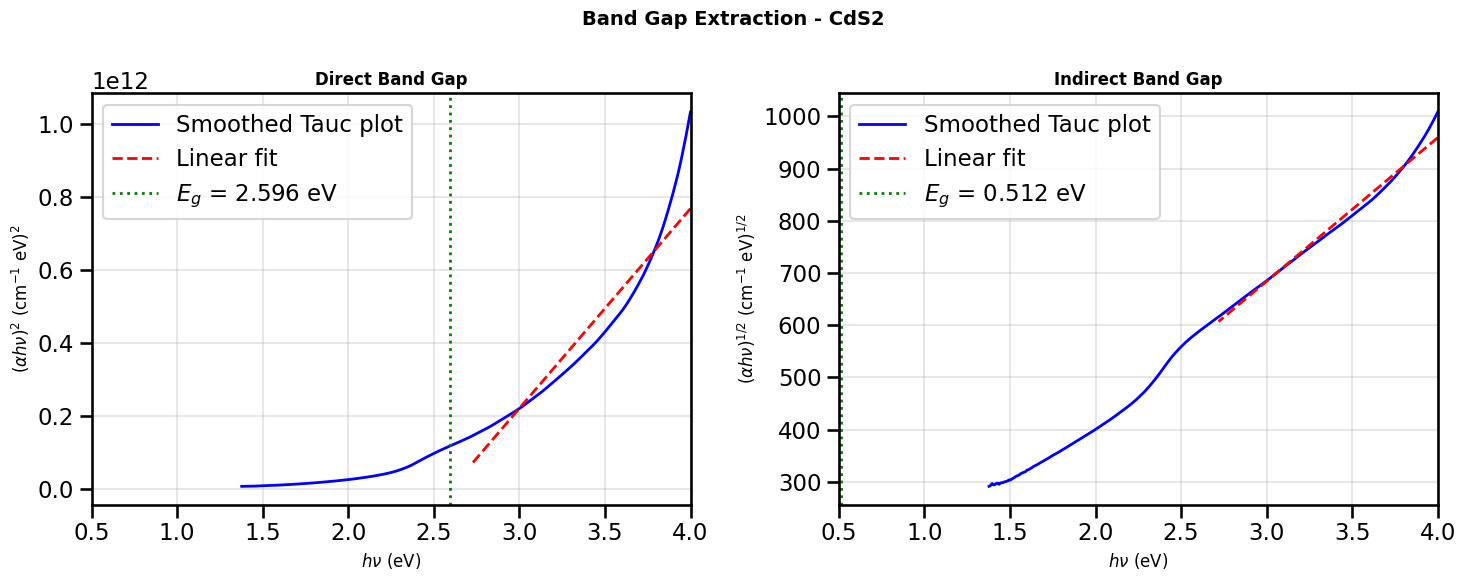

  Direct band gap: 2.596 eV
  Indirect band gap: 0.512 eV

Processing sample: CdS3


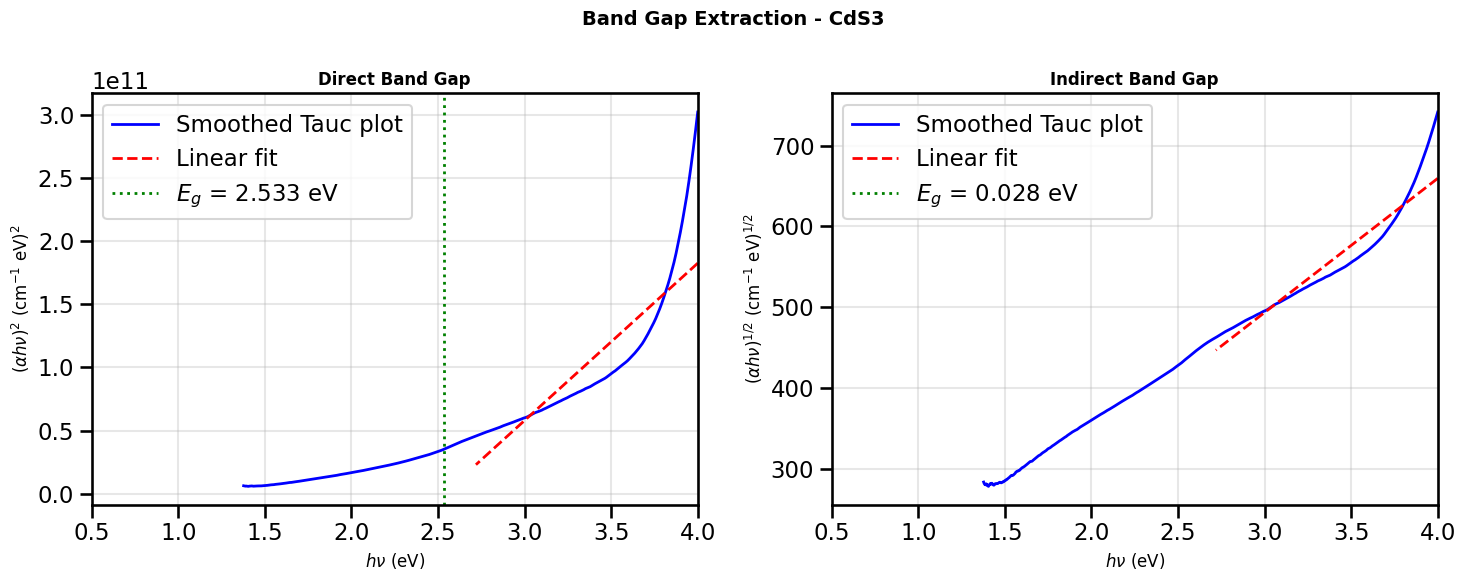

  Direct band gap: 2.533 eV
  Indirect band gap: 0.028 eV

BAND GAP SUMMARY
Sample     Type  Band Gap (eV)
  CdS1   Direct       2.675150
  CdS1 Indirect       0.845483
  CdS2   Direct       2.596495
  CdS2 Indirect       0.512441
  CdS3   Direct       2.532952
  CdS3 Indirect       0.028273


In [21]:
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
import os

gaps = []

# You can modify this parameter depending on where you expect your material's gap vs substrate gap
max_energy_limit = 4.0 

for k, data in res.items():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f'Tauc Plots for Sample: {k}', fontsize=16, fontweight='bold')
    
    x_hv = data['hv']
    
    # Evaluate both Direct (ax1) and Indirect (ax2)
    plot_configs = [
        {'ax': ax1, 'y_data': data['DA'], 'title': 'Direct Band Gap', 'ylabel': r'$(\alpha h\nu)^2$'},
        {'ax': ax2, 'y_data': data['IA'], 'title': 'Indirect Band Gap', 'ylabel': r'$(\alpha h\nu)^{1/2}$'}
    ]
    
    for config in plot_configs:
        ax = config['ax']
        y_val = config['y_data']
        
        # Filter data based on max energy to ignore substrate noise
        mask = (x_hv < max_energy_limit) & (x_hv > 1.0) # Look between 1.0 and max limit
        x_fit = x_hv[mask].reset_index(drop=True)
        y_fit = y_val[mask].reset_index(drop=True)
        
        if len(x_fit) < 25:
            ax.text(0.5, 0.5, 'Not enough data', transform=ax.transAxes)
            continue
            
        # 1. Smooth the data to calculate clean derivatives
        y_smooth = savgol_filter(y_fit, window_length=25, polyorder=2)
        
        # 2. Calculate the first derivative (gradient)
        d1 = np.gradient(y_smooth, x_fit)
        
        # 3. Find the linear region (maximum slope)
        # The perfectly linear region of the absorption edge has the maximum first derivative
        max_d1_idx = np.argmax(d1)
        
        x_0 = x_fit[max_d1_idx]
        y_0 = y_smooth[max_d1_idx]
        m = d1[max_d1_idx] # Slope
        c = y_0 - m * x_0  # Y-intercept
        
        # 4. Calculate optical gap from extrapolation line (x-intercept: y=0)
        x_cross = -c / m
        
        if config['title'] == 'Direct Band Gap':
            gaps.append({'Sample': k, 'Type': 'Direct', 'Gap (eV)': x_cross})
        else:
            gaps.append({'Sample': k, 'Type': 'Indirect', 'Gap (eV)': x_cross})
            
        # 5. Plotting
        ax.plot(x_fit, y_fit, 'b-', label='Original Data')
        
        # Calculate bounds for the extrapolation line
        y_max_extrapolate = 0.7 * np.amax(y_fit)
        x_extrapolate_start = x_cross
        x_extrapolate_end = (y_max_extrapolate - c) / m
        
        # Plot Extrapolation Line
        ax.plot([x_extrapolate_start, x_extrapolate_end], [0, y_max_extrapolate], 'r--', label='Linear Fit')
        
        # Mark the Band Gap Point
        ax.plot(x_cross, 0, 'go', markersize=8, label=f'Gap = {x_cross:.3f} eV')
        ax.axhline(0, color='black', linewidth=1)
        
        ax.set_xlabel(r'Photon Energy $h\nu$ (eV)')
        ax.set_ylabel(config['ylabel'])
        ax.set_title(config['title'])
        ax.set_xlim(1.0, max_energy_limit)
        
        # Let Matplotlib handle Y-limits naturally instead of setting an arbitrary upper bound
        ax.set_ylim(bottom=-0.05 * np.amax(y_fit)) 
        
        ax.legend()
        
    plt.tight_layout()
    plt_filename = f"Tauc_plot_{k}.png"
    plt.savefig(plt_filename, dpi=300)
    plt.show()

# Print Final Calculated Gaps
print("\n--- Summary of Calculated Band Gaps ---")
df_gaps = pd.DataFrame(gaps)
print(df_gaps.to_string(index=False))